# Cilium / cluster-network health -- node reachability, datapath pressure, mixin alerts

Cilium is the CNI **and** kube-proxy replacement ([docs/cluster-network.md](../docs/cluster-network.md)):
if it degrades, pods lose connectivity while the nodes still report `Ready`. This is the
pull-path companion to the deployed **cilium-mixin** (23 alert rules live in the Mimir ruler,
[tanka/environments/cilium-mixin](../tanka/environments/cilium-mixin/main.jsonnet)): node
reachability (the `CiliumUnreachableNodes` signal), agent/endpoint health, datapath pressure
(BPF/conntrack/NAT/policy maps, drops), and IPAM headroom.

**Motivating incident (2026-07-25).** A power/reboot event left **5 of 8 cilium-health
probers falsely reporting the two bare-metal nodes (acebase, lancer) as host-unreachable**
while the pod-overlay path stayed healthy the whole time -- stale in-agent prober state, not a
real partition, cleared by restarting the stale agents. The tell is in section 1: `unreachable
> 0` **but** the endpoint/overlay path healthy **and** the node rebooted recently ⇒ residue,
restart the agent; `unreachable > 0` with no recent reboot ⇒ investigate a real partition. See
[docs/bare-metal-nodes.md: DHCP-less boot](../docs/bare-metal-nodes.md#node-hostnames-and-dhcp-less-boot).

Cilium self-metrics are scraped **into Mimir**; their freshness is itself proof the
agent->Mimir path works. Thresholds are the deployed mixin's, cited inline. Companion no-monitoring
path is `kubectl` + `cilium-health status` (best-effort captured in section 1).

Design: [docs/notebooks.md](../docs/notebooks.md). Run from `notebooks/`:
`jupyter nbconvert --to notebook --execute --inplace cilium-health.ipynb`

In [1]:
mimir_url = "http://mimir-gateway.mimir.svc"   # cilium self-metrics are scraped INTO Mimir
loki_url = "http://loki.loki.svc:3100"         # for cilium's own logs
tenant = "tiles"          # X-Scope-OrgID for Mimir and Loki
namespace = "cilium"      # cilium agents/operator/envoy/hubble live here
lookback_hours = 24
range_step_s = 300
log_sample_lines = 100
reboot_window_h = 24      # a node booted within this window is "recently rebooted" (residue cue)
map_pressure_warn = 0.90  # cilium-mixin CiliumAgentBpfMapPressure / PolicyMapPressure: > 0.9 for 5m
capture_file = ""         # replay a prior raw capture JSON instead of querying live
output_dir = ""           # if set: write raw capture + agent stats there
debug = False

In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path
import nb_capture as nbc

plt.rcParams.update(nbc.MPL_STYLE)
NOTEBOOK = 'cilium-health'
cap = nbc.Capture(replay_file=capture_file, mimir_url=mimir_url, loki_url=loki_url,
                  tenant=tenant, namespace=namespace, lookback_hours=lookback_hours,
                  range_step_s=range_step_s, log_sample_lines=log_sample_lines,
                  reboot_window_h=reboot_window_h, map_pressure_warn=map_pressure_warn)
tenant, namespace = cap.meta['tenant'], cap.meta['namespace']
lookback_hours, step = cap.meta['lookback_hours'], cap.meta['range_step_s']
reboot_window_h, map_pressure_warn = cap.meta['reboot_window_h'], cap.meta['map_pressure_warn']
mm = nbc.Mimir(cap, cap.meta['mimir_url'], tenant)
lk = nbc.Loki(cap, cap.meta['loki_url'], tenant)
kube = nbc.Kube(cap)
print(f"mimir: {cap.meta['mimir_url']}  loki: {cap.meta['loki_url']}  tenant: {tenant}  "
      f"{'REPLAY of ' + cap.run_at if cap.replay else 'live'}")

mimir: http://mimir-gateway.mimir.svc  loki: http://loki.loki.svc:3100  tenant: tiles  live


In [3]:
# --- ASSUMPTIONS: verify the instruments before trusting any reading ---
# Fatal (whole notebook unassessable): cilium self-metrics absent/stale -- if cilium_version is
# not fresh in Mimir the agents are either dead or unscraped and every reading below is a lie.
# Also fatal-ish: fewer reporting agents than nodes (a blind spot -- an agent down or unscraped).
# Non-fatal: kube_* staleness degrades only the pod-health section.
assumption_warnings = []
STALE_S = 600

binfo = mm.q('buildinfo', 'cilium_version')
cilium_version = binfo[0]['metric'].get('version', 'unknown').split()[0] if binfo else 'unknown'
agents_reporting = len(binfo)
node_count = int(nbc.val(mm.q('node_count', 'count(kube_node_info)'), np.nan))

freshness = {
    'cilium self-metrics': 'max(timestamp(cilium_version))',
    'kube-state-metrics (cilium ns)': f'max(timestamp(kube_pod_info{{namespace="{namespace}"}}))',
}
inst_age = {}
for inst, query in freshness.items():
    ts = nbc.val(mm.q(f'fresh: {inst}', query))
    inst_age[inst] = cap.now - ts if not np.isnan(ts) else np.inf

print("=== ASSUMPTIONS ===")
print(f"  cilium {cilium_version}, {agents_reporting} agents reporting, {node_count} nodes")
for inst, age in inst_age.items():
    status = 'MISSING' if np.isinf(age) else f"newest sample {age:.0f}s old" + (' -- STALE' if age > STALE_S else '')
    print(f"  {inst:<32} {status}")

self_age = inst_age['cilium self-metrics']
if np.isinf(self_age) or self_age > STALE_S:
    raise RuntimeError(f"unassessable: cilium self-metrics stale or absent ({self_age:.0f}s) "
                       f"-- agents dead or unscraped; check `kubectl -n {namespace} get pods` directly")
if not np.isnan(node_count) and agents_reporting < node_count:
    assumption_warnings.append(f"only {agents_reporting} agents reporting for {node_count} nodes "
                               f"-- a node's cilium metrics are missing (blind spot)")
if inst_age['kube-state-metrics (cilium ns)'] > STALE_S:
    assumption_warnings.append("kube-state-metrics stale -- pod-health section degraded")

=== ASSUMPTIONS ===
  cilium 1.19.3, 8 agents reporting, 8 nodes
  cilium self-metrics              newest sample 3s old
  kube-state-metrics (cilium ns)   newest sample 6s old


In [4]:
# --- CAPTURE: fetch the complete observation up front, before any analysis ---
# Section 1 -- node reachability (the incident signal)
unreach_nodes = mm.q('unreachable_nodes', 'sum by (pod) (cilium_unreachable_nodes)')
unreach_heps = mm.q('unreachable_health_endpoints', 'sum by (pod) (cilium_unreachable_health_endpoints)')
# agent pod -> node / host_ip map (host-network DaemonSet pods)
agent_info = mm.q('agent_pod_info', f'kube_pod_info{{namespace="{namespace}", created_by_name="cilium"}}')
node_uptime_h = nbc.by(mm.q('node_uptime_h', '(time() - node_boot_time_seconds) / 3600'), 'instance')
# best-effort: the actual per-node reachability matrix from one agent (read-only exec)
agent_pods = sorted({r['metric'].get('pod', '') for r in unreach_nodes if r['metric'].get('pod')})
health_probe = cap.exec('cilium_health_status',
    ['kubectl', 'exec', '-n', namespace, agent_pods[0] if agent_pods else 'cilium', '-c',
     'cilium-agent', '--', 'cilium-health', 'status']) if agent_pods else {'rc': -1, 'stderr': 'no agent pod'}

# Section 3 -- agent & endpoint health
ds_desired = nbc.val(mm.q('ds_desired', 'max(kube_daemonset_status_desired_number_scheduled{daemonset="cilium"})'), np.nan)
ds_ready = nbc.val(mm.q('ds_ready', 'max(kube_daemonset_status_number_ready{daemonset="cilium"})'), np.nan)
restarts = nbc.by(mm.q('restarts_by_pod', f'sum by (pod) (kube_pod_container_status_restarts_total{{namespace="{namespace}"}})'), 'pod')
crashloop = mm.q('crashloop', f'kube_pod_container_status_waiting_reason{{namespace="{namespace}", reason="CrashLoopBackOff"}} == 1')
ep_states = nbc.by(mm.q('endpoint_states', 'sum by (endpoint_state) (cilium_endpoint_state)'), 'endpoint_state')

# Section 4 -- datapath pressure (mixin: BpfMapPressure/PolicyMapPressure > 0.9)
map_pressure = nbc.by(mm.q('bpf_map_pressure', 'max by (map_name) (cilium_bpf_map_pressure)'), 'map_name')
ip_used = nbc.by(mm.q('ip_addresses', 'sum by (family) (cilium_ip_addresses)'), 'family')

# Section 5 -- drops (mixin: CT/NAT table-full are specific drop reasons). Total over lookback +
# a short recent slice, so a past spike does not read as ongoing (notebooks.md episodic rule).
drops_window = nbc.by(mm.q('drops_window', f'sum by (reason) (increase(cilium_drop_count_total[{lookback_hours}h]))'), 'reason')
drops_recent = nbc.by(mm.q('drops_recent', 'sum by (reason) (increase(cilium_drop_count_total[1h]))'), 'reason')
# mixin's two drop-based alerts key off these exact reasons; generic reasons are background noise.
CT_DROP_REASON = 'CT: Map insertion failed'      # -> CiliumAgentConntrackTableFull (critical)
NAT_DROP_REASON = 'No mapping for NAT masquerade' # -> CiliumAgentNatTableFull (critical)
f_drops = nbc.frame(mm.qr('drops_trend', 'sum by (reason) (rate(cilium_drop_count_total[5m]))', lookback_hours, step), 'reason')

# Section 2 -- mixin alert state (rules API) + ALERTS-series and alertmanager cross-checks
rules_rec = mm.get('cilium_rules', '/prometheus/api/v1/rules', type='alert')
alerts_series = mm.q('cilium_alerts_series', 'count by (alertname, alertstate) (ALERTS{alertname=~"Cilium.*"})')
am_rec = mm.get('alertmanager_alerts', '/alertmanager/api/v2/alerts')
am_alerts = am_rec.get('json', []) if 'json' in am_rec else []

# Section 6 -- wide-angle logs (cilium ns): level volume, error/warn sample, raw tail
f_loglevel = nbc.frame(lk.metric_range('log_volume_by_level',
    f'sum by (detected_level) (count_over_time({{namespace="{namespace}"}}[10m]))', lookback_hours, 600), 'detected_level')
log_errwarn = lk.lines('log_errwarn_sample', f'{{namespace="{namespace}"}} | detected_level=~"error|warn"', lookback_hours, 50)
log_tail = lk.lines('log_tail_sample', f'{{namespace="{namespace}"}}', lookback_hours, log_sample_lines)
print(f"captured {len(cap.data['calls'])} raw calls")

captured 25 raw calls


In [5]:
# --- SECTION 1: NODE REACHABILITY -- the CiliumUnreachableNodes signal ---
# mixin CiliumUnreachableNodes: sum by (pod)(cilium_unreachable_nodes) > 0 for 15m (severity info).
# Two probe paths per node in cilium-health: HOST (node IP ICMP/HTTP:4240) and ENDPOINT (overlay,
# pod-CIDR health IP). unreachable_nodes counts host-path failures; unreachable_health_endpoints
# counts overlay-path failures. Host-fail + overlay-OK on a recently-rebooted node is the
# stale-prober residue signature (2026-07-25); both failing is a real partition.
pod_node = {r['metric']['pod']: r['metric'].get('node', r['metric'].get('host_ip', '?'))
            for r in agent_info}
def by_node(res):
    out = {}
    for r in res:
        pod = r['metric'].get('pod', '?')
        out[pod_node.get(pod, pod)] = int(float(r['value'][1]))
    return out
un_host = by_node(unreach_nodes)
un_overlay = by_node(unreach_heps)

# index = actual cilium nodes only (node_uptime_h also carries non-cluster node-exporters, e.g. raconteur)
cnodes = sorted(set(un_host) | set(un_overlay))
reach = pd.DataFrame({
    'uptime_h': pd.Series({n: node_uptime_h.get(n, np.nan) for n in cnodes}).round(),
    'unreachable_host': pd.Series(un_host),
    'unreachable_overlay': pd.Series(un_overlay),
})
reach['recently_rebooted'] = reach['uptime_h'] < reboot_window_h
reach = reach.sort_values(['unreachable_host', 'uptime_h'], ascending=[False, True])
print("per-agent reachability (rows = agent's node; counts = nodes THIS agent cannot reach):")
print(reach.to_string(float_format=lambda v: f'{v:,.0f}', na_rep='-'))

total_host = int(reach['unreachable_host'].fillna(0).sum())
total_overlay = int(reach['unreachable_overlay'].fillna(0).sum())
if total_host == 0 and total_overlay == 0:
    print("\n  OK: every agent reaches every node on both the host and overlay paths (0 unreachable).")
else:
    residue = reach[(reach['unreachable_host'] > 0) & (reach['unreachable_overlay'].fillna(0) == 0)]
    partition = reach[(reach['unreachable_host'] > 0) & (reach['unreachable_overlay'] > 0)]
    if len(residue):
        print(f"\n  HOST-only failures on {list(residue.index)} -- overlay path fine. If the "
              f"UNreachable nodes rebooted recently this is stale-prober residue: restart those "
              f"agents (kubectl -n {namespace} delete pod <agent>). See the 2026-07-25 incident.")
    if len(partition):
        print(f"\n  BOTH paths failing from {list(partition.index)} -- a real partition, NOT residue. "
              f"Investigate node/network before restarting anything.")

# best-effort actual matrix (which nodes) from one agent
if health_probe.get('rc') == 0:
    print("\ncilium-health status (one agent -- the actual per-node matrix):")
    print(health_probe['stdout'])
else:
    print(f"\n(cilium-health exec unavailable: {health_probe.get('stderr','')[:200]} -- "
          f"metrics above still authoritative)")

per-agent reachability (rows = agent's node; counts = nodes THIS agent cannot reach):
            uptime_h  unreachable_host  unreachable_overlay  recently_rebooted
tiles-wk-1       146                 0                    0              False
acebase          148                 0                    0              False
lancer           148                 0                    0              False
tiles-cp-1       479                 0                    0              False
tiles-cp-2       479                 0                    0              False
tiles-cp-3       479                 0                    0              False
tiles-wk-2       479                 0                    0              False
tiles-wk-3       479                 0                    0              False

  OK: every agent reaches every node on both the host and overlay paths (0 unreachable).

cilium-health status (one agent -- the actual per-node matrix):
Cluster health:                  8/8 reachable  

In [6]:
# --- SECTION 2: MIXIN ALERT STATE -- one-glance over all deployed Cilium* rules ---
# Two independent views (notebooks.md cross-check rule): the ruler's rule states vs the ALERTS
# series vs the alertmanager API. Disagreement is itself a finding.
rule_rows = []
if 'json' in rules_rec and rules_rec['json'].get('status') == 'success':
    for g in rules_rec['json']['data']['groups']:
        for r in g['rules']:
            if r.get('type') == 'alerting' and 'Cilium' in r.get('name', ''):
                rule_rows.append((r['name'], r.get('state', '?'), r.get('health', '?'),
                                  r.get('labels', {}).get('severity', '?')))
rules_df = pd.DataFrame(rule_rows, columns=['alert', 'state', 'health', 'severity'])
by_state = rules_df['state'].value_counts().to_dict() if not rules_df.empty else {}
bad_health = rules_df[rules_df['health'] != 'ok'] if not rules_df.empty else rules_df
firing_pending = rules_df[rules_df['state'].isin(['firing', 'pending'])] if not rules_df.empty else rules_df
print(f"cilium-mixin: {len(rules_df)} alert rules deployed -- states {by_state}")
if len(firing_pending):
    print("  NOT inactive:")
    print(firing_pending.to_string(index=False))
else:
    print("  all inactive (nothing firing or pending).")
if len(bad_health):
    print(f"  WARNING: {len(bad_health)} rules not evaluating cleanly (health != ok):")
    print(bad_health.to_string(index=False))

# cross-check: ALERTS series + alertmanager API
series_view = {f"{r['metric'].get('alertname')}/{r['metric'].get('alertstate')}": int(float(r['value'][1]))
               for r in alerts_series}
am_cilium = sorted({a['labels'].get('alertname') for a in am_alerts
                    if 'Cilium' in a['labels'].get('alertname', '')})
print(f"\n  ALERTS series (Cilium*): {series_view or 'none'}")
print(f"  alertmanager firing (Cilium*): {am_cilium or 'none'}")
ruler_firing = set(firing_pending[firing_pending['state'] == 'firing']['alert']) if len(firing_pending) else set()
if ruler_firing ^ set(am_cilium):
    print(f"  NOTE: ruler-firing vs alertmanager-firing disagree ({ruler_firing} vs {set(am_cilium)}) "
          f"-- one view is stale; treat as a finding.")

cilium-mixin: 23 alert rules deployed -- states {'inactive': 23}
  all inactive (nothing firing or pending).

  ALERTS series (Cilium*): none
  alertmanager firing (Cilium*): none


In [7]:
# --- SECTION 3: AGENT & ENDPOINT HEALTH ---
print(f"cilium DaemonSet: {ds_ready:.0f}/{ds_desired:.0f} ready")
if not np.isnan(ds_desired) and ds_ready < ds_desired:
    print(f"  WARNING: {ds_desired - ds_ready:.0f} agent(s) not ready")
crashloopers = sorted({r['metric']['pod'] for r in crashloop})
hot_restarts = {p: int(v) for p, v in sorted(restarts.items(), key=lambda x: -x[1]) if v > 0}
print(f"CrashLoopBackOff now: {crashloopers or 'none'}")
print(f"restarts by pod (nonzero): {hot_restarts or 'none'}")

# endpoint states: mixin CiliumAgentEndpointFailures fires on endpoint_state="invalid".
print(f"\nendpoint states (cluster-wide): { {k: int(v) for k, v in ep_states.items()} }")
invalid = int(ep_states.get('invalid', 0))
notready = int(ep_states.get('not-ready', 0)) + int(ep_states.get('disconnecting', 0))
if invalid:
    print(f"  ! {invalid} endpoints in 'invalid' state -- mixin CiliumAgentEndpointFailures territory")
if notready:
    print(f"  note: {notready} endpoints not-ready/disconnecting (transient during pod churn; "
          f"persistent is a finding)")

cilium DaemonSet: 8/8 ready
CrashLoopBackOff now: none
restarts by pod (nonzero): {'cilium-gm6ds': 9, 'cilium-fh8vc': 2, 'cilium-kqwx4': 1, 'cilium-operator-88f954974-xjhz4': 1}

endpoint states (cluster-wide): {'disconnecting': 0, 'ready': 91, 'regenerating': 0, 'restoring': 0, 'waiting-for-identity': 0, 'waiting-to-regenerate': 0}


In [8]:
# --- SECTION 4: DATAPATH PRESSURE -- BPF map fill (mixin: > 0.9 for 5m) + IPAM headroom ---
mp = pd.Series(map_pressure).sort_values(ascending=False)
print(f"BPF map pressure (fill fraction), top maps -- mixin warns at > {map_pressure_warn}:")
print(mp.head(12).to_string(float_format=lambda v: f'{v:.3f}'))
hot_maps = {m: round(v, 3) for m, v in mp.items() if v > map_pressure_warn}
if hot_maps:
    policy_hot = {m: v for m, v in hot_maps.items() if m.startswith('cilium_policy_')}
    print(f"  ! maps over {map_pressure_warn}: {hot_maps}"
          + (f"  (policy maps -> CiliumAgentPolicyMapPressure)" if policy_hot else ""))
else:
    print(f"  OK: all maps below {map_pressure_warn} (peak {mp.max():.3f} on '{mp.idxmax()}')" if len(mp) else "  (no map pressure series)")

print(f"\nIPAM allocated addresses by family: { {k: int(v) for k, v in ip_used.items()} }  "
      f"(pod CIDR is a /18 per node-pool; exhaustion would surface as "
      f"CiliumOperatorLowAvailableIpamIps -- see section 2)")

BPF map pressure (fill fraction), top maps -- mixin warns at > 0.9:
ct4_global        0.088
ct_any4_global    0.043
lb4_services_v2   0.005
lb4_reverse_nat   0.002
lb4_backends_v3   0.002
throttle          0.001
lxc               0.000
ipcache_v2        0.000
  OK: all maps below 0.9 (peak 0.088 on 'ct4_global')

IPAM allocated addresses by family: {'ipv4': 91, 'ipv6': 0}  (pod CIDR is a /18 per node-pool; exhaustion would surface as CiliumOperatorLowAvailableIpamIps -- see section 2)


cilium drops by reason (increase over 24h vs recent 1h):
                         total_24h  recent_1h
Unsupported L3 protocol      1,589         69
Stale or unroutable IP         123          0
  (generic reasons above are background non-IP/L2 noise -- the mixin does not alert on them; only the two table-full reasons below are actionable)


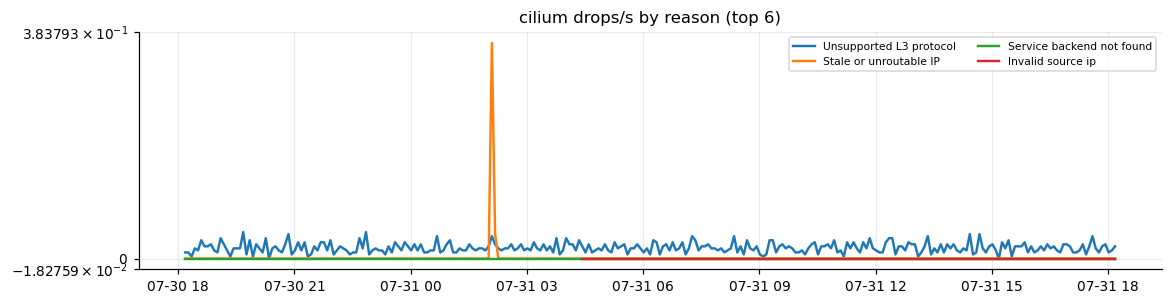

In [9]:
# --- SECTION 5: DATAPATH DROPS -- totals over window + recent 24h slice, by reason ---
# notebooks.md episodic-counter rule: a windowed mean dresses a past spike as ongoing; report the
# total AND a recent slice, and let the finding say "historical, not ongoing" when 24h is empty.
# Only the two table-full reasons are mixin-alerting (critical); generic reasons (Unsupported L3
# protocol, Stale/unroutable IP, ...) are ordinary background L2/non-IP noise -- shown, NOT flagged.
drops = pd.DataFrame({f'total_{lookback_hours}h': pd.Series(drops_window),
                      'recent_1h': pd.Series(drops_recent)}).fillna(0.0)
drops = drops[(drops.T != 0).any()].sort_values(f'total_{lookback_hours}h', ascending=False)
ct_recent = float(drops_recent.get(CT_DROP_REASON, 0.0))
nat_recent = float(drops_recent.get(NAT_DROP_REASON, 0.0))
table_full = {r: round(v) for r, v in {CT_DROP_REASON: ct_recent, NAT_DROP_REASON: nat_recent}.items() if v > 0}
if drops.empty:
    print(f"no packet drops recorded in the last {lookback_hours}h -- datapath clean.")
else:
    print(f"cilium drops by reason (increase over {lookback_hours}h vs recent 1h):")
    print(drops.to_string(float_format=lambda v: f'{v:,.0f}'))
    print("  (generic reasons above are background non-IP/L2 noise -- the mixin does not alert on "
          "them; only the two table-full reasons below are actionable)")
if table_full:
    print(f"  ! table-full drops in the last 1h: {table_full} -- mixin "
          f"CiliumAgentConntrackTableFull / NatTableFull (critical) territory")

fig, ax = plt.subplots(figsize=(12, 2.8))
if f_drops.empty or f_drops.abs().to_numpy().sum() == 0:
    ax.text(0.5, 0.5, f'no drops in the {lookback_hours}h window', ha='center', va='center',
            transform=ax.transAxes, color='0.4'); ax.grid(False)
else:
    top = f_drops.sum().sort_values(ascending=False).head(6).index
    for c in top:
        ax.plot(f_drops.index, f_drops[c], lw=1.6, label=str(c)[:36])
    ax.legend(fontsize=7, ncol=2); ax.set_yscale('symlog')
ax.set_title('cilium drops/s by reason (top 6)')
nbc.show(fig)

log lines/s by detected_level (mean over 24h): {'Info': 0.17, 'Warning': 0.01, 'error': 0.08, 'info': 0.07, 'unknown': 0.04, 'warn': 0.11}


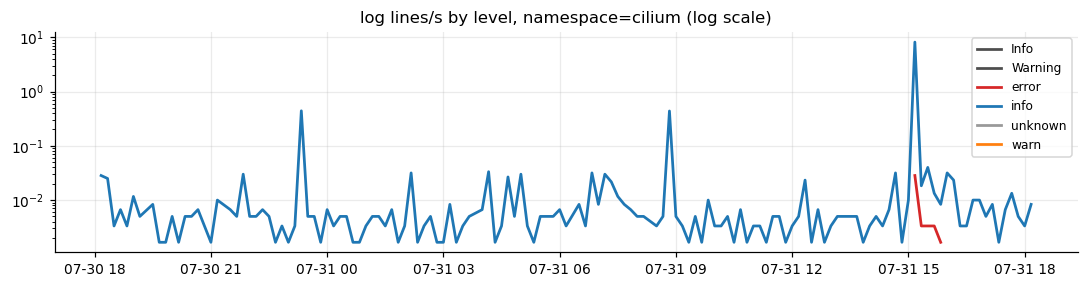


newest error/warn lines (up to 50 in 24h, newest first):
  31 15:42:36 cilium-9q85m                 time=2026-07-31T15:42:36.722053284Z level=error msg="Error(s) while full reconciling l2 responder map" module=agent.datapath.l2-re
  31 15:37:36 cilium-9q85m                 time=2026-07-31T15:37:36.721304519Z level=error msg="Error(s) while full reconciling l2 responder map" module=agent.datapath.l2-re
  31 15:32:36 cilium-9q85m                 time=2026-07-31T15:32:36.721185479Z level=error msg="Error(s) while full reconciling l2 responder map" module=agent.datapath.l2-re
  31 15:27:36 cilium-9q85m                 time=2026-07-31T15:27:36.72117321Z level=error msg="Error(s) while full reconciling l2 responder map" module=agent.datapath.l2-res
  31 15:22:36 cilium-9q85m                 time=2026-07-31T15:22:36.721325498Z level=error msg="Error(s) while full reconciling l2 responder map" module=agent.datapath.l2-re
  31 15:17:36 cilium-9q85m                 time=2026-07-31T15:17:36.7218

In [10]:
# --- SECTION 6: WIDE-ANGLE LOGS (cilium ns) -- proves collection alive, catches the uncurated ---
lvl_colors = {'error': 'C3', 'warn': 'C1', 'info': 'C0', 'debug': 'C4', 'unknown': '0.6'}
lvl_rate_mean = {c: round(float(f_loglevel[c].mean() / 600), 2) for c in f_loglevel.columns} if not f_loglevel.empty else {}
print(f"log lines/s by detected_level (mean over {lookback_hours}h): {lvl_rate_mean}")
errish = sum(f_loglevel.get(lvl, pd.Series(dtype=float)).sum() for lvl in ('error', 'warn'))
if errish > 0 and not log_errwarn:
    print("WARNING: level counts show error/warn but the sample query returned none -- sample query "
          "broken, do NOT read as 'no errors'")

fig, ax = plt.subplots(figsize=(12, 2.6))
if f_loglevel.empty:
    ax.text(0.5, 0.5, 'no log volume in window', ha='center', va='center', transform=ax.transAxes, color='0.4'); ax.grid(False)
else:
    for c in f_loglevel.columns:
        ax.plot(f_loglevel.index, f_loglevel[c] / 600, lw=1.8, label=c, color=lvl_colors.get(c, '0.3'))
    ax.legend(fontsize=8); ax.set_yscale('log')
ax.set_title(f'log lines/s by level, namespace={namespace} (log scale)')
nbc.show(fig)

print(f"\nnewest error/warn lines (up to 50 in {lookback_hours}h, newest first):")
for ts, st, line in log_errwarn[:25]:
    print(f"  {ts:%d %H:%M:%S} {st.get('pod', '?')[:28]:<28} {line[:130]}")
if len(log_errwarn) > 25:
    print(f"  ... {len(log_errwarn) - 25} more captured (see raw capture)")

print(f"\nlast {min(len(log_tail), 30)} raw lines from namespace={namespace} (unfiltered cross-check):")
for ts, st, line in log_tail[:30]:
    print(f"  {ts:%H:%M:%S} {st.get('pod', '?')[:28]:<28} {line[:130]}")

In [11]:
# --- SUMMARY: assumption ledger first, then findings vs explicit (mixin) thresholds ---
findings = []
if total_host or total_overlay:
    findings.append(f"cilium reports unreachable nodes (host {total_host}, overlay {total_overlay}) "
                    f"-- see section 1 for residue-vs-partition")
if not np.isnan(ds_desired) and ds_ready < ds_desired:
    findings.append(f"cilium agents not ready: {ds_ready:.0f}/{ds_desired:.0f}")
if crashloopers:
    findings.append(f"agent pods in CrashLoopBackOff: {crashloopers}")
if int(ep_states.get('invalid', 0)):
    findings.append(f"{int(ep_states['invalid'])} endpoints in invalid state (EndpointFailures)")
if hot_maps:
    findings.append(f"BPF maps over {map_pressure_warn}: {hot_maps}")
if table_full:
    findings.append(f"datapath table-full drops (last 1h): {table_full} -- conntrack/NAT capacity")
if len(firing_pending):
    findings.append(f"cilium-mixin alerts not inactive: {list(firing_pending['alert'])}")

print("=" * 60)
print("CILIUM / CLUSTER-NETWORK HEALTH SUMMARY")
print("=" * 60)
print(f"run:      {cap.run_at}  ({cap.mode})")
print(f"cilium:   {cilium_version}, {agents_reporting} agents / {node_count} nodes, tenant {tenant}, lookback {lookback_hours}h")
print()
print("Assumptions: " + ("all instruments fresh" if not assumption_warnings else "; ".join(assumption_warnings)))
print()
if findings:
    print("Findings:")
    for f in findings:
        print(f"  ! {f}")
else:
    print("Findings: none -- all nodes reachable both paths, agents ready, endpoints healthy, "
          "map pressure low, no recent drops, mixin all inactive")
print()
print(f"  Reachability: host-unreachable {total_host}, overlay-unreachable {total_overlay}")
print(f"  Agents:       {ds_ready:.0f}/{ds_desired:.0f} ready; crashloops {crashloopers or 'none'}")
print(f"  Datapath:     peak map pressure {pd.Series(map_pressure).max():.3f}; "
      f"table-full drops(1h) {table_full or 'none'}")
print(f"  Mixin:        {len(rules_df)} rules, states {by_state}")

CILIUM / CLUSTER-NETWORK HEALTH SUMMARY
run:      2026-07-31T18:10:38.491152+00:00  (live)
cilium:   1.19.3, 8 agents / 8 nodes, tenant tiles, lookback 24h

Assumptions: all instruments fresh

Findings: none -- all nodes reachable both paths, agents ready, endpoints healthy, map pressure low, no recent drops, mixin all inactive

  Reachability: host-unreachable 0, overlay-unreachable 0
  Agents:       8/8 ready; crashloops none
  Datapath:     peak map pressure 0.088; table-full drops(1h) none
  Mixin:        23 rules, states {'inactive': 23}


In [12]:
# AGENT-READABLE STATS -- consolidated JSON; assumption status leads.
def _n(v):
    return None if v is None or (isinstance(v, float) and not np.isfinite(v)) else round(float(v), 4)

def _i(v):
    return int(v) if v is not None and pd.notna(v) else 0

agent_stats = {
    'notebook': f'{NOTEBOOK}.ipynb',
    'run_at': cap.run_at,
    'mode': cap.mode,
    'cilium_version': cilium_version,
    'agents_reporting': agents_reporting,
    'node_count': node_count,
    'lookback_hours': lookback_hours,
    'assumptions': {'status': 'ok' if not assumption_warnings else 'degraded',
                    'warnings': assumption_warnings,
                    'instrument_age_s': {k: _n(v) for k, v in inst_age.items()}},
    'findings': findings,
    'reachability': {'unreachable_host_total': total_host, 'unreachable_overlay_total': total_overlay,
                     'by_node': {n: {'host': _i(reach['unreachable_host'].get(n)),
                                     'overlay': _i(reach['unreachable_overlay'].get(n)),
                                     'uptime_h': _n(reach['uptime_h'].get(n)),
                                     'recently_rebooted': bool(reach['recently_rebooted'].get(n, False))}
                                 for n in reach.index},
                     'health_exec_ok': health_probe.get('rc') == 0},
    'agents': {'ds_ready': _n(ds_ready), 'ds_desired': _n(ds_desired),
               'crashloop': crashloopers, 'restarts_by_pod': hot_restarts},
    'endpoints': {k: int(v) for k, v in ep_states.items()},
    'datapath': {'map_pressure_peak': _n(pd.Series(map_pressure).max() if map_pressure else np.nan),
                 'maps_over_threshold': hot_maps,
                 'ip_addresses': {k: int(v) for k, v in ip_used.items()},
                 'drops_table_full_1h': table_full,
                 'drops_total_window': {r: round(v) for r, v in drops_window.items() if v > 0}},
    'mixin': {'rules_total': len(rules_df), 'by_state': by_state,
              'not_inactive': list(firing_pending['alert']) if len(firing_pending) else [],
              'alertmanager_firing': am_cilium},
    'logs': {'lines_per_s_mean_by_level': lvl_rate_mean, 'errwarn_captured': len(log_errwarn),
             'errwarn_newest': [f"{ts:%Y-%m-%d %H:%M:%S} {st.get('pod', '?')} {line[:150]}"
                                for ts, st, line in log_errwarn[:10]]},
}
print(json.dumps(agent_stats, indent=1))

if output_dir:
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    cap.save(out / f'{NOTEBOOK}.capture.json')
    (out / f'{NOTEBOOK}.stats.json').write_text(json.dumps(agent_stats, indent=2))
    print(f"wrote {out / f'{NOTEBOOK}.capture.json'} and {out / f'{NOTEBOOK}.stats.json'}")

{
 "notebook": "cilium-health.ipynb",
 "run_at": "2026-07-31T18:10:38.491152+00:00",
 "mode": "live",
 "cilium_version": "1.19.3",
 "agents_reporting": 8,
 "node_count": 8,
 "lookback_hours": 24,
 "assumptions": {
  "status": "ok",
  "warnings": [],
  "instrument_age_s": {
   "cilium self-metrics": 3.0641,
   "kube-state-metrics (cilium ns)": 5.6131
  }
 },
 "findings": [],
 "reachability": {
  "unreachable_host_total": 0,
  "unreachable_overlay_total": 0,
  "by_node": {
   "tiles-wk-1": {
    "host": 0,
    "overlay": 0,
    "uptime_h": 146.0,
    "recently_rebooted": false
   },
   "acebase": {
    "host": 0,
    "overlay": 0,
    "uptime_h": 148.0,
    "recently_rebooted": false
   },
   "lancer": {
    "host": 0,
    "overlay": 0,
    "uptime_h": 148.0,
    "recently_rebooted": false
   },
   "tiles-cp-1": {
    "host": 0,
    "overlay": 0,
    "uptime_h": 479.0,
    "recently_rebooted": false
   },
   "tiles-cp-2": {
    "host": 0,
    "overlay": 0,
    "uptime_h": 479.0,
    "rec